# Exploratory Data Analysis on FedEx Delivery Operations

In [53]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#for displaying the plots inside the jupyter notebook
%matplotlib inline
#for improving the visualization style
sns.set_style("whitegrid")
#for ignoring the warning messages
import warnings
warnings.filterwarnings("ignore")
import os

output_folder = r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\outputs"

os.makedirs(output_folder, exist_ok=True)

In [6]:
#loading the dataset
df = pd.read_csv(r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\dataset\fedex_deliveries.csv")

In [8]:
#displaying the first 5 rows
df.head()

,ShipmentID,Origin,Destination,Pickup_Date,Delivery_Date,Delivery_Status,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delay_Reason
0,SHP00001,Chicago,Las Vegas,2025-06-13,2025-06-18,Delayed,152,Air,89.12,493.24,Business,Operational
1,SHP00002,Denver,San Francisco,2025-01-08,2025-01-16,Delayed,945,Air,28.30,657.66,Retail,Weather
2,SHP00003,Dallas,San Francisco,2025-05-31,2025-06-04,Delivered,76,Ground,91.18,335.85,Retail,NaN
3,SHP00004,Chicago,Las Vegas,2025-01-27,2025-02-02,Delayed,1606,Air,12.06,838.61,Business,Customs
4,SHP00005,Atlanta,Boston,2025-05-22,2025-05-28,Delayed,2624,Ground,74.41,1206.66,Business,Operational


In [10]:
#checking the missinng values
df.isnull().sum()

ShipmentID           0
Origin               0
Destination          0
Pickup_Date          0
Delivery_Date        0
Delivery_Status      0
Distance_KM          0
Shipment_Mode        0
Weight_KG            0
Cost_USD             0
Customer_Segment     0
Delay_Reason        63
dtype: int64

In [17]:
#checking the number of rows and coloumns(checking the dataset shape)
print("rows", df.shape[0])
print("columns", df.shape[1])
df.shape

rows 300
columns 12


(300, 12)

In [18]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ShipmentID        300 non-null    object 
 1   Origin            300 non-null    object 
 2   Destination       300 non-null    object 
 3   Pickup_Date       300 non-null    object 
 4   Delivery_Date     300 non-null    object 
 5   Delivery_Status   300 non-null    object 
 6   Distance_KM       300 non-null    int64  
 7   Shipment_Mode     300 non-null    object 
 8   Weight_KG         300 non-null    float64
 9   Cost_USD          300 non-null    float64
 10  Customer_Segment  300 non-null    object 
 11  Delay_Reason      237 non-null    object 
dtypes: float64(2), int64(1), object(9)
memory usage: 28.3+ KB


In [21]:
#dataset description
df.describe()

,Distance_KM,Weight_KG,Cost_USD
count,300.000000,300.000000,300.000000
mean,1509.073333,60.109833,852.075467
std,860.156516,35.209672,328.012389
min,68.000000,0.580000,162.890000
25%,778.000000,29.557500,592.200000
50%,1456.000000,60.440000,839.625000
75%,2277.750000,90.385000,1093.652500
max,3000.000000,119.740000,1565.460000


In [25]:
#convertinng the date columns
df["Pickup_Date"] = pd.to_datetime(df["Pickup_Date"])
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])

In [27]:
#creating the Delivery_Time_Days 
df["Delivery_Time_Days"] = (
    df["Delivery_Date"] - df["Pickup_Date"]
).dt.days

df.head()

,ShipmentID,Origin,Destination,Pickup_Date,Delivery_Date,Delivery_Status,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delay_Reason,Delivery_Time_Days
0,SHP00001,Chicago,Las Vegas,2025-06-13,2025-06-18,Delayed,152,Air,89.12,493.24,Business,Operational,5
1,SHP00002,Denver,San Francisco,2025-01-08,2025-01-16,Delayed,945,Air,28.30,657.66,Retail,Weather,8
2,SHP00003,Dallas,San Francisco,2025-05-31,2025-06-04,Delivered,76,Ground,91.18,335.85,Retail,Customs,4
3,SHP00004,Chicago,Las Vegas,2025-01-27,2025-02-02,Delayed,1606,Air,12.06,838.61,Business,Customs,6
4,SHP00005,Atlanta,Boston,2025-05-22,2025-05-28,Delayed,2624,Ground,74.41,1206.66,Business,Operational,6


## Outlier Detection


Text(0.5, 1.0, 'outliers in Weight_KG')

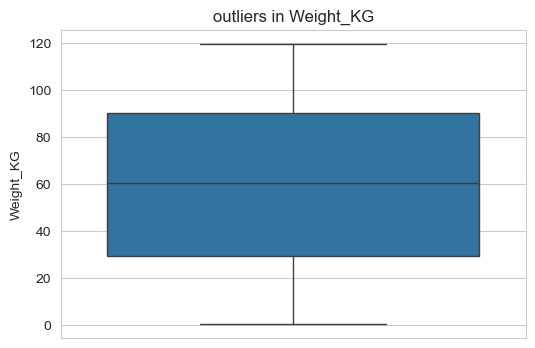

In [29]:

#Visualize outliers in Weight_KG, Cost_USD, and Distance_KM using boxplots.
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Weight_KG"])
plt.title("outliers in Weight_KG")

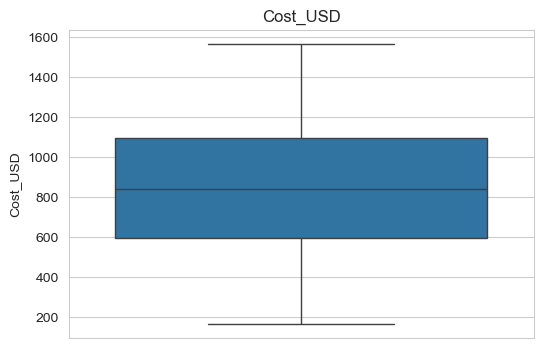

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Cost_USD"])
plt.title("outliers in Cost_USD")
plt.show()

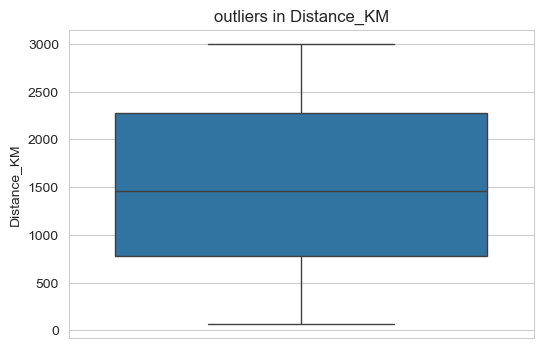

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Distance_KM"])
plt.title("outliers in Distance_KM")
plt.show()

visualization

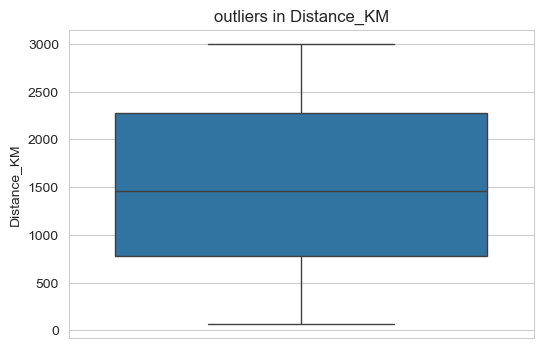

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Distance_KM"])
plt.title("outliers in Distance_KM")
plt.show()

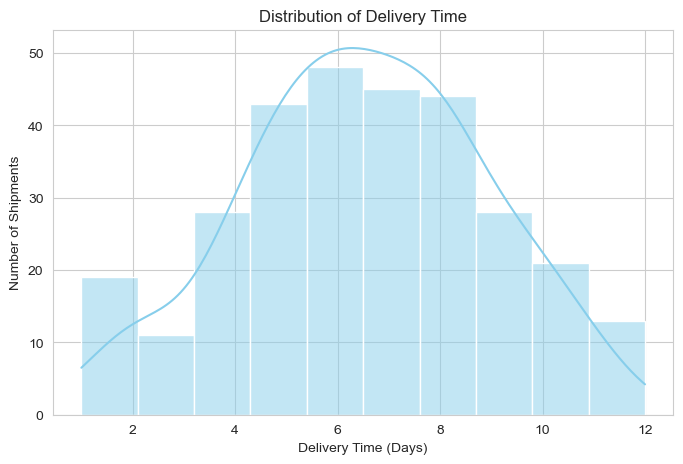

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df["Delivery_Time_Days"],
             bins=10,
             kde=True,
             color="skyblue")

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")

# Save image
plt.savefig(
    r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\outputs\delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [38]:
average_delivery = df["Delivery_Time_Days"].mean()

print("Average Delivery Time:", round(average_delivery,2), "Days")

Average Delivery Time: 6.52 Days


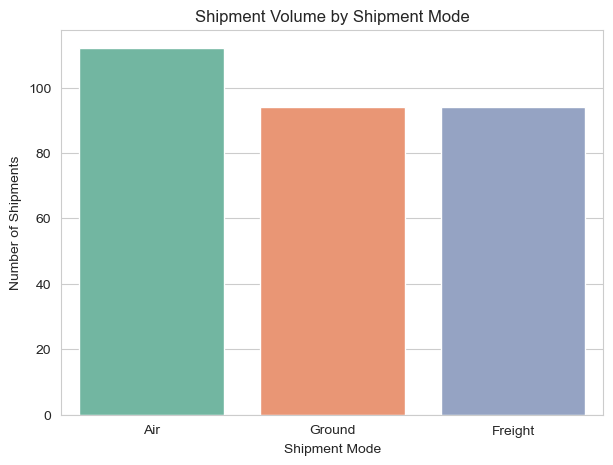

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Shipment_Mode", palette="Set2")

plt.title("Shipment Volume by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")

# Save first
plt.savefig(
    os.path.join(output_folder, "shipment_mode_bar.png"),
    dpi=300,
    bbox_inches="tight"
)

# Then display
plt.show()

In [43]:
## Average Shipping Cost by Customer Segment
avg_cost = df.groupby("Customer_Segment")["Cost_USD"].mean()
avg_cost

Customer_Segment
Business      799.661237
Government    860.639684
Retail        891.617870
Name: Cost_USD, dtype: float64

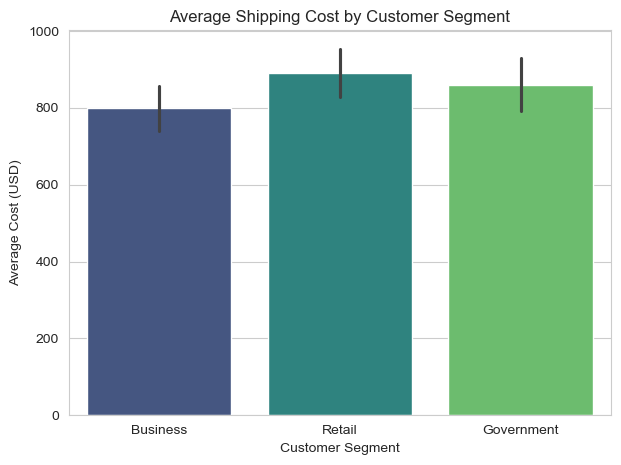

In [45]:
plt.figure(figsize=(7,5))

sns.barplot(data=df,
            x="Customer_Segment",
            y="Cost_USD",
            estimator=np.mean,
            palette="viridis")

plt.title("Average Shipping Cost by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Cost (USD)")
plt.savefig(r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\outputs\customer_segment_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

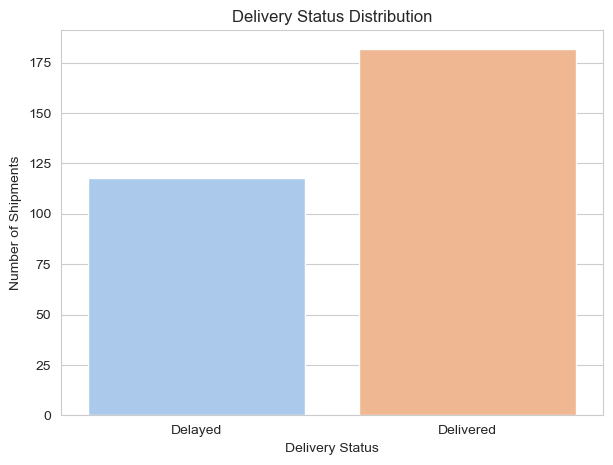

In [47]:
## Delivery Status Analysis
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Delivery_Status",
              palette="pastel")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")
plt.savefig(r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\outputs\delivery_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

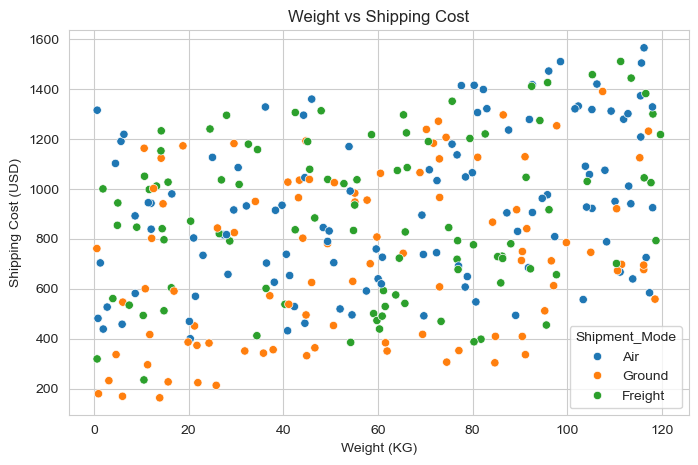

In [50]:
## Weight vs Shipping Cost
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="Weight_KG",
                y="Cost_USD",
                hue="Shipment_Mode")

plt.title("Weight vs Shipping Cost")
plt.xlabel("Weight (KG)")
plt.ylabel("Shipping Cost (USD)")
plt.savefig(r"C:\Users\Shaik Fayaz Ahammed\Desktop\FedEx_EDA_Project\outputs\Weight_Shipping_Cost.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

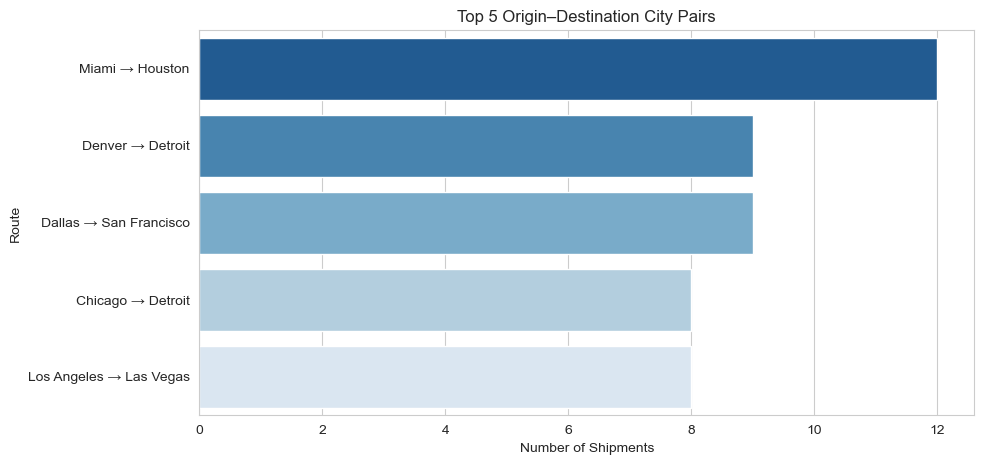

In [58]:
## Step 19: Top 5 Origin–Destination City Pairs
top_routes = (
    df.groupby(["Origin", "Destination"])
      .size()
      .reset_index(name="Shipment_Count")
      .sort_values(by="Shipment_Count", ascending=False)
      .head(5)
)

top_routes

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_routes,
    x="Shipment_Count",
    y=top_routes["Origin"] + " → " + top_routes["Destination"],
    palette="Blues_r"
)

plt.title("Top 5 Origin–Destination City Pairs")
plt.xlabel("Number of Shipments")
plt.ylabel("Route")

plt.savefig(
    os.path.join(output_folder, "top_city_pairs.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

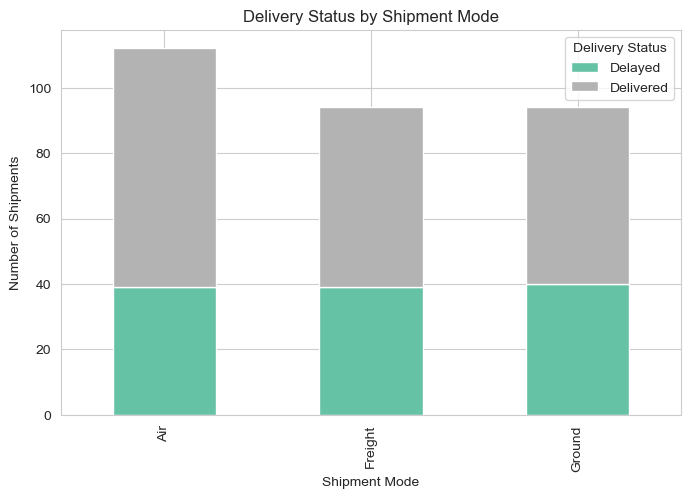

In [60]:
## Delivery Delays by Shipment Mode
delay_mode = pd.crosstab(
    df["Shipment_Mode"],
    df["Delivery_Status"]
)

delay_mode
#vizualitation
delay_mode.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set2"
)

plt.title("Delivery Status by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")

plt.legend(title="Delivery Status")

plt.savefig(
    os.path.join(output_folder, "delays_by_mode.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

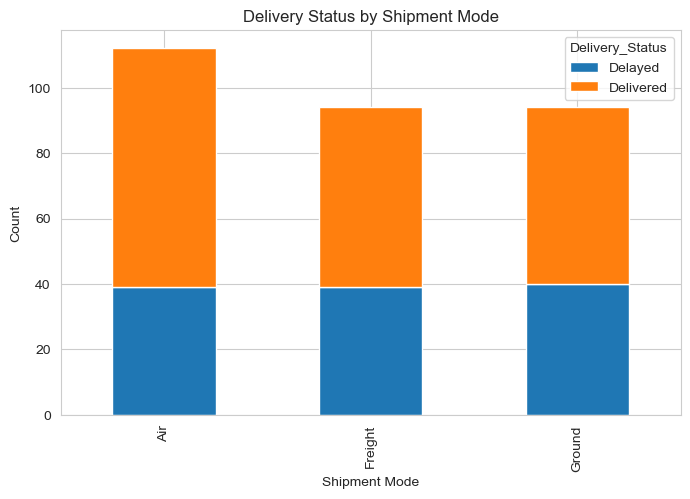

In [61]:
## Delivery Delays by Shipment Mode
pd.crosstab(df["Shipment_Mode"], df["Delivery_Status"]).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Delivery Status by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Count")

plt.savefig(os.path.join(output_folder, "delays_by_mode.png"), dpi=300, bbox_inches="tight")

plt.show()

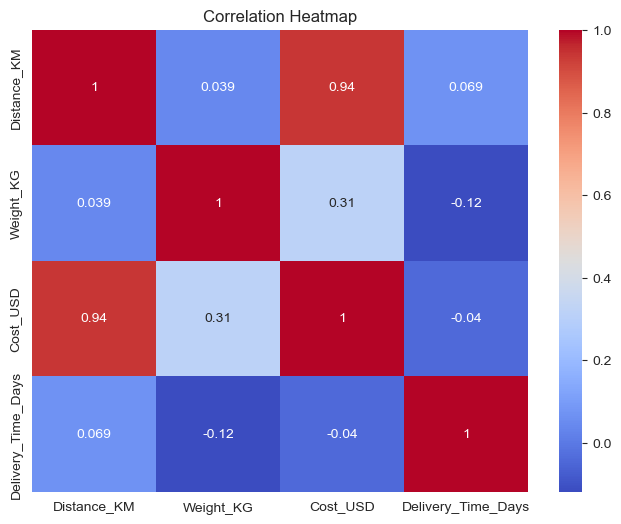

In [62]:
## Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"), dpi=300, bbox_inches="tight")

plt.show()

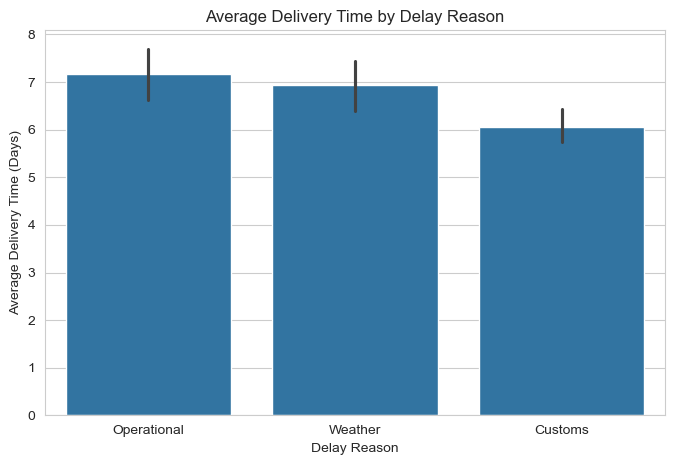

In [63]:
#delay reason
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Delay_Reason",
    y="Delivery_Time_Days",
    estimator=np.mean
)

plt.title("Average Delivery Time by Delay Reason")
plt.xlabel("Delay Reason")
plt.ylabel("Average Delivery Time (Days)")

plt.savefig(os.path.join(output_folder, "delay_reason_analysis.png"), dpi=300, bbox_inches="tight")

plt.show()

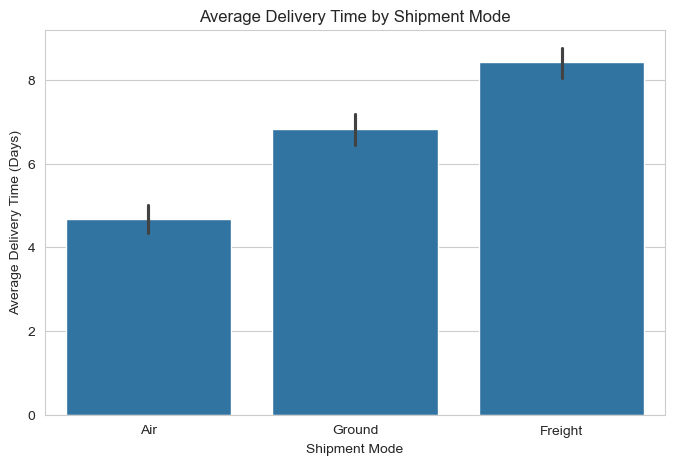

In [64]:
# Average Delivery Time by Shipment Mode
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Shipment_Mode",
    y="Delivery_Time_Days",
    estimator=np.mean
)

plt.title("Average Delivery Time by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Delivery Time (Days)")

plt.savefig(os.path.join(output_folder, "delivery_time_by_mode.png"), dpi=300, bbox_inches="tight")

plt.show()

# Business Recommendations

### 1. Key Operational Inefficiencies

Analysis indicates that shipment delays are mainly associated with operational issues, weather conditions, and customs clearance. Freight shipments generally require longer delivery times, which may reduce operational efficiency.

### 2. Shipment Mode Allocation

Short-distance shipments can be shifted from Freight to Ground transportation where feasible. Time-sensitive shipments should be prioritized for Air transport to improve delivery performance.

### 3. Reducing Shipping Costs

Optimize shipment routes, consolidate smaller shipments, and improve vehicle utilization to reduce transportation costs. Selecting the most appropriate shipment mode based on distance and package weight can also lower shipping expenses.

### 4. Improving Customer Satisfaction

Provide customers with real-time shipment tracking and proactive notifications for expected delays. Better communication and accurate delivery updates can improve customer trust and overall satisfaction.